#### **FACTIBILIDAD DE LA SOLUCIÓN**

In [895]:
import pandas as pd 
import matplotlib.pyplot as plt
from importlib import reload

import Clases.caja as caja_module
reload(caja_module)
from Clases.caja import Caja

import Clases.producto as producto_module
reload(producto_module)
from Clases.producto import Producto

catalogo_productos = pd.read_csv("Datos-finales/catalogo_productos.csv")
especificaciones_cajas = pd.read_csv("Datos-finales/especificaciones_cajas.csv")
operaciones_planta = pd.read_csv("Datos-finales/operaciones_planta.csv")
procurement_cajas = pd.read_csv("Datos-finales/procurement_cajas.csv")

Guardamos primero los tipos de cajas y productos en listas de python.

In [896]:
caja_compras_merge = especificaciones_cajas.merge(procurement_cajas,
                                                  on="caja_tipo_id")

cajas = [
    Caja(
        caja_id = row["caja_tipo_id"],
        dim_interior_ancho = row["caja_interior_ancho"],
        dim_interior_largo = row["caja_interior_largo"],
        dim_interior_alto = row["caja_interior_alto"],
        costo_unitario = row['costo_unitario_base']
    )
    for _, row in caja_compras_merge.iterrows()
]

cajas[:5]

[<Caja 016d196c89dcfcb306b853a776a879b9 | Int: 248.0 x 383.0 x 224.0mm | Compra Total: 0>,
 <Caja 01a2a319402ed2155292c04d8748e16f | Int: 282.0 x 380.0 x 185.0mm | Compra Total: 0>,
 <Caja 026560e43f3fc6afe0ce89d7ddf61626 | Int: 290.0 x 390.0 x 184.0mm | Compra Total: 0>,
 <Caja 02d7c6680102bd11e067c00c9b71ab9c | Int: 248.0 x 383.0 x 268.0mm | Compra Total: 0>,
 <Caja 0378f85c226113f4ac40fd360217bb8a | Int: 289.0 x 390.0 x 224.0mm | Compra Total: 0>]

In [897]:
operaciones_planta_aux = operaciones_planta.drop('codigo_producto', axis=1) 
prod_op_merge = pd.concat([catalogo_productos, operaciones_planta_aux], axis=1)

productos = [
    Producto(
        codigo_producto = row['codigo_producto'],
        cantidad_paquetes = row['cantidad_paquetes'],
        peso_paquete = row['peso_neto_paquete'],
        demanda_buenos_aires = row['volumen_producto_planta_buenos_aires'],
        demanda_curitiba = row['volumen_producto_planta_curitiba'],
        demanda_santiago = row['volumen_producto_planta_santiago'],
        demanda_monterrey = row['volumen_producto_planta_monterrey'],
        demanda_bakersfield = row['volumen_producto_planta_bakersfield'],
        dim_producto_ancho = row['dim_producto_ancho'], 
        dim_producto_largo = row['dim_producto_largo'],
        dim_producto_alto = row['dim_producto_alto']
    )
    for _, row in prod_op_merge.iterrows()
]

productos[:5]

[<Producto BR0001 | Dim Prod: 285.0 x 386.0 x 303.0mm | Demanda Total: 1546613>,
 <Producto BR0002 | Dim Prod: 290.0 x 390.0 x 260.0mm | Demanda Total: 139211>,
 <Producto BR0003 | Dim Prod: 287.0 x 388.0 x 164.0mm | Demanda Total: 172506>,
 <Producto BR0004 | Dim Prod: 290.0 x 390.0 x 224.0mm | Demanda Total: 271715>,
 <Producto BR0005 | Dim Prod: 285.0 x 386.0 x 253.0mm | Demanda Total: 7586>]

#### **Factibilidad 1: Tipos de cajas asignables por dimensión**

La idea sería ver cuántos tipos de cajas se pueden asignar por producto, considerando la restricción de cada dimensión interna. Sabemos que volumen_interno >= volumen_producto, y que además cada dimensión interna no puede superar más del 10% de la original.

In [898]:
cajas_asignables_dimension = {}

for producto in productos:
    cajas_asignables = []
    for caja in cajas:
        if caja.es_asignable_por_dimension(producto):
            cajas_asignables.append(caja)
    
    cajas_asignables_dimension[producto] = cajas_asignables

Veamos en detalle cuántos tipos de cajas son asignables por cada producto.

In [899]:
df_dimension = pd.DataFrame([
    {
        'codigo_producto': producto.codigo_producto,
        'cantidad_cajas_asignables': len(cajas_asign),
    }
    for producto, cajas_asign in cajas_asignables_dimension.items()
])

df_dimension = df_dimension.sort_values('cantidad_cajas_asignables', ascending=False)
df_dimension

,codigo_producto,cantidad_cajas_asignables
326,BR0317,24
325,BR0316,24
104,BR0103,22
29,BR0030,21
291,BR0284,21
...,...,...
123,BR0122,1
115,BR0114,1
57,BR0058,1
358,BR0345,1


Observemos que el espacio de búsqueda se redujo significativamente, y como máximo se pueden asignar 24 tipos de cajas a un mismo producto, siendo el caso de BR0317. 

Veamos cómo se distribuye esta cantidad en un gráfico.

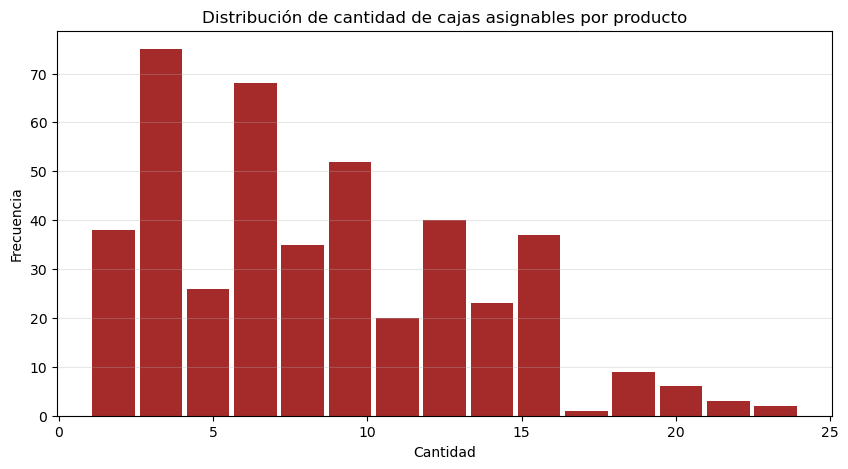

In [900]:
plt.figure(figsize=(10, 5))
plt.hist(df_dimension['cantidad_cajas_asignables'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de cantidad de cajas asignables por producto')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Podemos notar que la mayoría de productos suelen poder utilizar hasta 10 tipos de cajas, y que sólo pocos casos alcanzan hasta los 20 o más. Esto nos genera definitivamente una gran ventaja en la optimización posterior.

Por otro lado, podría llegar a ser interesante ver cuántos productos son asignables por tipo de caja, y en particular ver cuál es el tipo de caja con más posibilidad de ser asignado. 

Además de aumentar los descuentos por los volúmenes altos, esto reduciría significativamente la cantidad de tipos de cajas utilizados.

In [901]:
cajas_conteo_productos = {}
for caja in cajas:
    contador = 0
    for producto in productos:
        if caja.es_asignable_por_dimension(producto):
            contador += 1
    cajas_conteo_productos[caja] = contador

df_productos_por_caja = pd.DataFrame(
    list(cajas_conteo_productos.items()),
    columns=['caja_id', 'cantidad_productos']
)

df_productos_por_caja = df_productos_por_caja.sort_values('cantidad_productos', ascending=False)
df_productos_por_caja

,caja_id,cantidad_productos
190,<Caja ef0525f0911fd36073c2b10f4d81dfd5 | Int: ...,63
38,<Caja 2bcfb295bee600aa6914bbd06f5891b6 | Int: ...,61
189,<Caja edebe6dd9669ec03369694b6dbbd4c54 | Int: ...,58
67,<Caja 4beade23001bd00ced8d86ccb4e4606b | Int: ...,57
164,<Caja d20c085d39ceb93f1f9dbe59c29a4786 | Int: ...,53
...,...,...
104,<Caja 78a9769d0348193b1b9ddcf416284c9f | Int: ...,1
153,<Caja bf4810af2c3a721abe2b0f8698dc4313 | Int: ...,1
176,<Caja e04ec2d8fbdb602a330f68e409a51828 | Int: ...,1
181,<Caja e53adffdcabd1407844bfa9dabe381fb | Int: ...,1


Notemos que la mayoría de tipos de cajas pueden ser asignados a varios productos, siendo el valor máximo un total de 63 productos. La selección óptima explica que comprar más de esos tipos de cajas permitiría que haya un mayor descuento por compra.

Exportemos los resultados a csv:

In [902]:
datos = []

for producto, cajas in cajas_asignables_dimension.items():
    ids_cajas = [caja.caja_id for caja in cajas]  
    datos.append({
        'codigo_producto': producto.codigo_producto,
        'volumen_producto_total': producto.demanda_total(),
        'cajas_asignables_id': '; '.join(ids_cajas)
    })


df_cajas_asignables = pd.DataFrame(datos)

# Reordenamos los index según el orden de catalogo original
df_cajas_asignables = prod_op_merge[['codigo_producto', 'volumen_producto_total']].merge(
    df_cajas_asignables, 
    on=['codigo_producto', 'volumen_producto_total'], 
    how='inner'
)

df_cajas_asignables.to_csv('4r.factibilidad.csv', index=False)